# Tugas 2 - Klasifikasi Diabetes dengan Naive Bayes dan Logistic Regression

| Nama | NRP |
|------|-----|
| Muhammad Dzaky Haidar| 5054251039|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Pima Indians Diabetes Dataset. Dataset bisa diakses melalui link berikut:\
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

Tujuan utama dari tugas ini adalah membangun model Naive Bayes dan Logistic Regression untuk mengklasifikasikan apakah seorang pasien menderita diabetes atau tidak.

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Gaussian Naive Bayes dan Logistic Regression.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil kedua model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
)

In [2]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv("diabetes.csv")

display(df.head())
print("Jumlah baris dan kolom:", df.shape)
df.info()
display(df.describe())
display(df.isna().sum().rename("Missing value"))

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


Jumlah baris dan kolom: (768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


,Missing value
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


,Proporsi
Outcome,
0,0.651042
1,0.348958


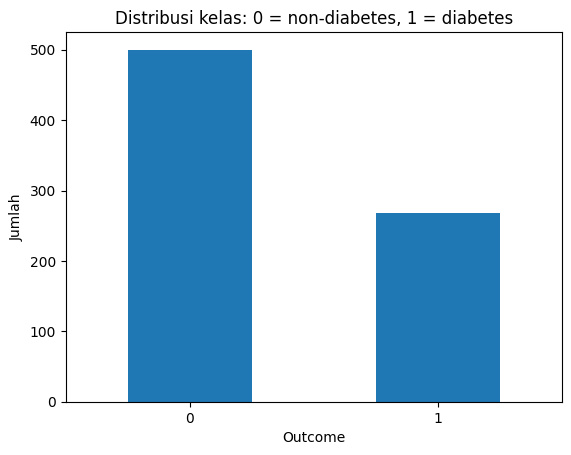

In [3]:
# Tampilkan distribusi kelas target (Outcome) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
display(df["Outcome"].value_counts(normalize=True).rename("Proporsi"))

df["Outcome"].value_counts().sort_index().plot.bar(
    title="Distribusi kelas: 0 = non-diabetes, 1 = diabetes", rot=0
)
plt.ylabel("Jumlah")
plt.show()

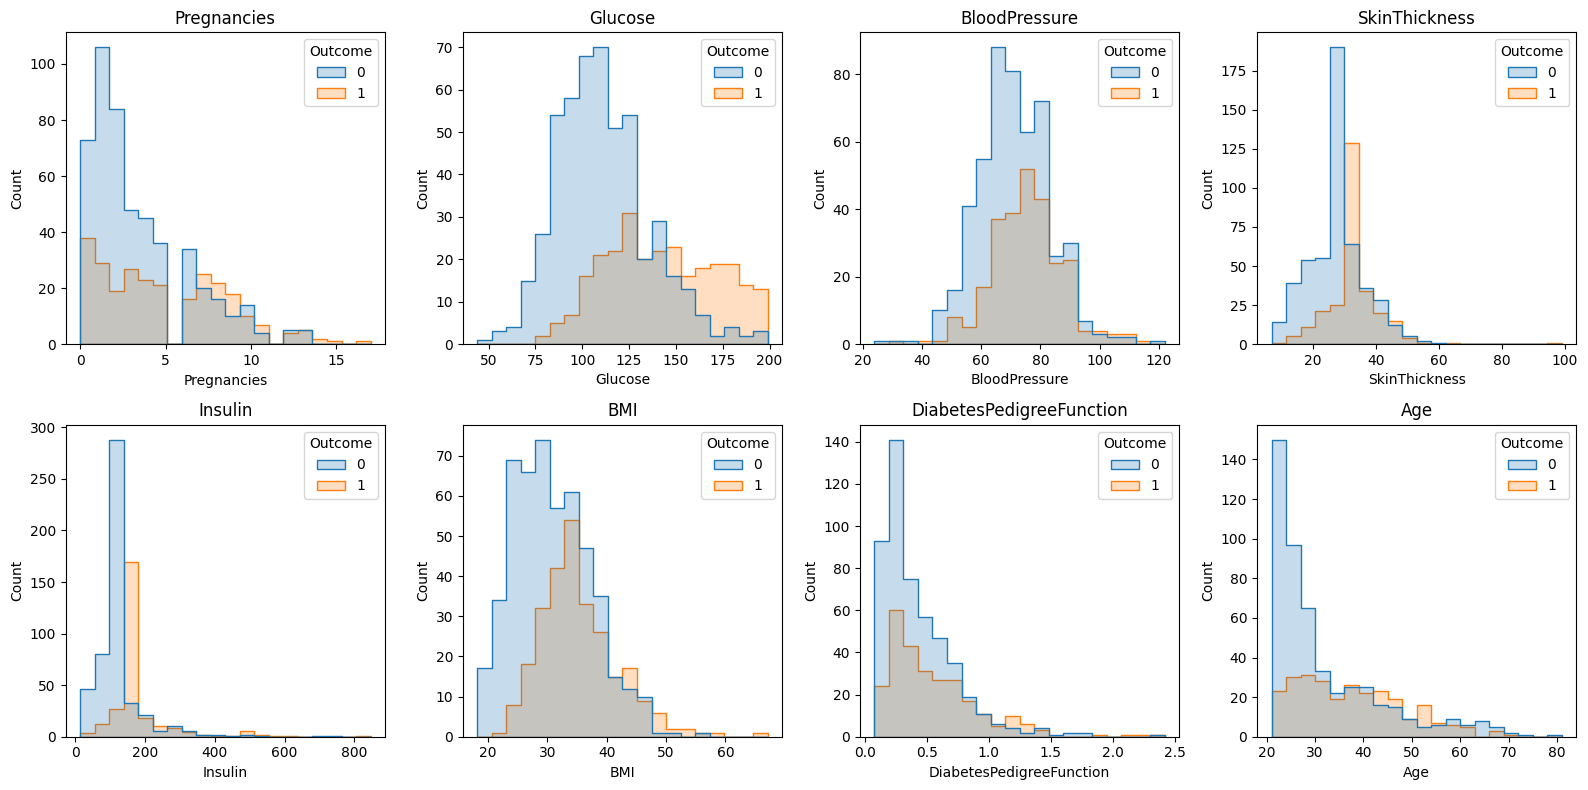

In [4]:
# Tampilkan distribusi setiap fitur menggunakan histogram atau KDE plot, dibedakan berdasarkan kelas Outcome.
features = df.drop(columns="Outcome").columns
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, feature in zip(axes.flat, features):
    sns.histplot(
        data=df, x=feature, hue="Outcome",
        bins=20, element="step", ax=ax
    )
    ax.set_title(feature)

plt.tight_layout()
plt.show()

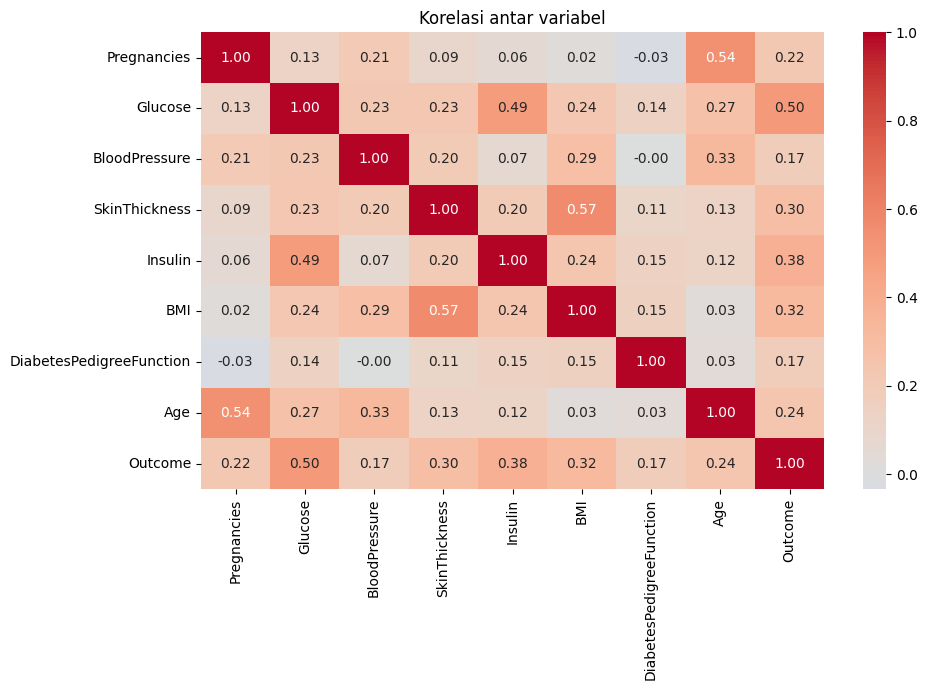

In [5]:
# Tampilkan heatmap korelasi antar fitur.
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Korelasi antar variabel")
plt.tight_layout()
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [6]:
# Beberapa kolom seperti Glucose, BloodPressure, SkinThickness, Insulin, dan BMI memiliki nilai 0 yang secara medis tidak mungkin.
# Identifikasi kolom-kolom tersebut dan hitung jumlah nilai 0 pada masing-masing kolom.
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
display(df[zero_cols].eq(0).sum().rename("Jumlah nilai 0"))

,Jumlah nilai 0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0


In [7]:
# Tangani nilai 0 tersebut dengan strategi yang sesuai (misalnya imputasi dengan median atau mean).
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
df[zero_cols] = df[zero_cols].replace(0, np.nan)
imputer = SimpleImputer(strategy="median")

In [9]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = df.drop(columns="Outcome")
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (614, 8) Test: (154, 8)


In [10]:
# Lakukan feature scaling menggunakan StandardScaler.
# Fit hanya pada train set, kemudian transform pada train set dan test set.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Eksperimen Model

## 3.1 Gaussian Naive Bayes

Gunakan GaussianNB karena semua fitur pada dataset ini bersifat numerik kontinu.

In [11]:
# Inisialisasi dan latih model Gaussian Naive Bayes menggunakan train set.
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)

GaussianNB()

In [12]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
pred_nb = nb.predict(X_test_scaled)
prob_nb = nb.predict_proba(X_test_scaled)[:, 1]

## 3.2 Logistic Regression

In [13]:
# Inisialisasi dan latih model Logistic Regression menggunakan train set.
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [14]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
pred_lr = lr.predict(X_test_scaled)
prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

# 4. Evaluasi Model

In [15]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.
results = {
    "Gaussian NB": (pred_nb, prob_nb),
    "Logistic Regression": (pred_lr, prob_lr)
}

scores = pd.DataFrame({
    name: {
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "AUC": roc_auc_score(y_test, prob)
    }
    for name, (pred, prob) in results.items()
}).T

display(scores.round(4))

,Accuracy,Precision,Recall,F1,AUC
Gaussian NB,0.7273,0.6034,0.6481,0.6250,0.8017
Logistic Regression,0.7078,0.5882,0.5556,0.5714,0.8263


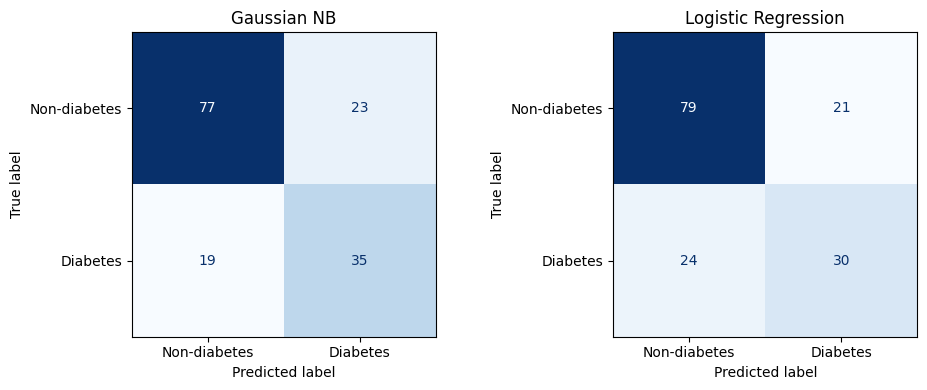

In [16]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (name, (pred, _)) in zip(axes, results.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, pred, labels=[0, 1],
        display_labels=["Non-diabetes", "Diabetes"],
        cmap="Blues", colorbar=False, ax=ax
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()

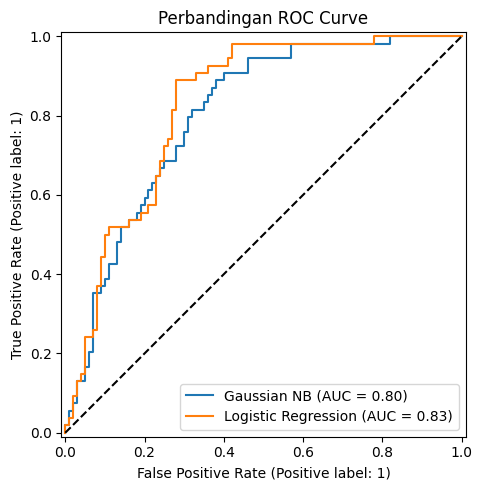

In [17]:
# Tampilkan ROC Curve kedua model dalam satu plot beserta nilai AUC masing-masing.
fig, ax = plt.subplots(figsize=(6, 5))

for name, (_, prob) in results.items():
    RocCurveDisplay.from_predictions(y_test, prob, name=name, ax=ax)

ax.plot([0, 1], [0, 1], "k--")
ax.set_title("Perbandingan ROC Curve")
plt.tight_layout()
plt.show()

,Koefisien
BloodPressure,-0.004245
Age,0.159826
DiabetesPedigreeFunction,0.174725
SkinThickness,0.294976
Pregnancies,0.337228
BMI,0.466051
Insulin,0.614170
Glucose,0.934942


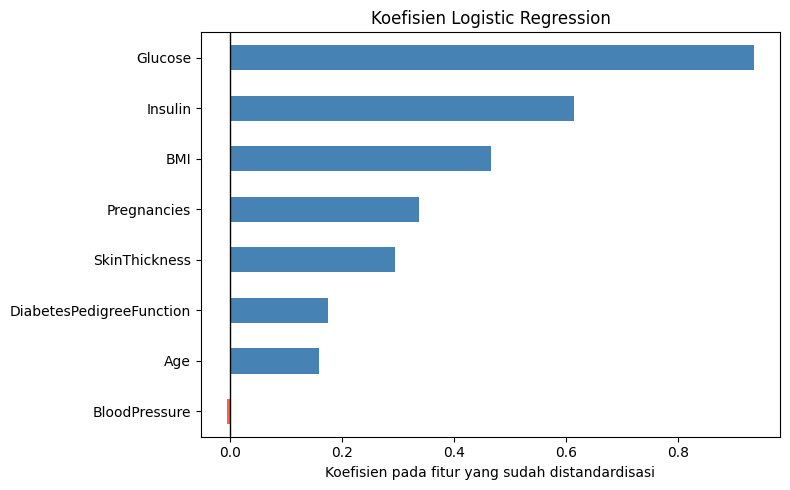

In [18]:
# Khusus Logistic Regression: tampilkan koefisien setiap fitur dalam bentuk bar chart horizontal.
# Koefisien positif menandakan fitur meningkatkan probabilitas diabetes, negatif sebaliknya.
coef = pd.Series(lr.coef_[0], index=X.columns).sort_values()
display(coef.rename("Koefisien"))

coef.plot.barh(
    figsize=(8, 5),
    color=["tomato" if value < 0 else "steelblue" for value in coef]
)
plt.axvline(0, color="black", linewidth=1)
plt.title("Koefisien Logistic Regression")
plt.xlabel("Koefisien pada fitur yang sudah distandardisasi")
plt.tight_layout()
plt.show()

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan. Bandingkan performa Gaussian Naive Bayes dan Logistic Regression berdasarkan hasil evaluasi. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.

1. Dataset terdiri atas 768 data dengan 8 fitur dan satu target Outcome. Proporsi non-diabetes sebesar 65,10% dan diabetes sebesar 34,90%, sehingga kelas non-diabetes lebih dominan. Oleh karena itu, evaluasi perlu mempertimbangkan precision, recall, dan F1-Score selain accuracy.

2. Pada dataset yang digunakan, tidak ditemukan missing value maupun nilai nol pada Glucose, BloodPressure, SkinThickness, Insulin, dan BMI. Dengan demikian, langkah penggantian nol dan imputasi tidak mengubah nilai data. Data dibagi menjadi 614 data train dan 154 data test menggunakan stratifikasi. Imputer dan StandardScaler hanya di-fit pada data train.

3. Gaussian NB memperoleh accuracy 72,73%, precision 60,34%, recall 64,81%, F1-Score 0,6250, dan AUC 0,8017. Logistic Regression memperoleh accuracy 70,78%, precision 58,82%, recall 55,56%, F1-Score 0,5714, dan AUC 0,8263. Gaussian NB unggul pada metrik klasifikasi dengan ambang bawaan, sedangkan Logistic Regression memiliki AUC lebih tinggi.

4. Confusion matrix Gaussian NB menunjukkan 77 data non-diabetes dan 35 data diabetes diprediksi dengan benar. Kesalahannya terdiri atas 23 data non-diabetes yang diprediksi diabetes dan 19 data diabetes yang diprediksi non-diabetes. Logistic Regression memprediksi 79 data non-diabetes dan 30 data diabetes dengan benar, dengan 21 false positive dan 24 false negative. Gaussian NB berhasil mendeteksi 5 kasus diabetes lebih banyak, tetapi menghasilkan 2 false positive tambahan.

5. Gaussian NB memodelkan distribusi setiap fitur dalam masing-masing kelas sebagai Gaussian dan mengasumsikan independensi antarfitur terhadap kelas. Logistic Regression memodelkan log-odds kelas diabetes sebagai kombinasi linear fitur. Perbedaan asumsi tersebut dapat menghasilkan prediksi berbeda. Namun, hasil satu pembagian data belum cukup untuk menyimpulkan bahwa salah satu model selalu lebih unggul.

6. AUC Logistic Regression yang lebih tinggi menunjukkan kemampuan pemeringkatan kelas yang lebih baik pada data test, meskipun recall dan F1-Score pada ambang bawaan lebih rendah. Hal ini menunjukkan bahwa kemampuan membedakan kelas dan hasil klasifikasi pada satu ambang keputusan merupakan dua aspek yang berbeda.

7. Pada Logistic Regression, Glucose memiliki koefisien positif terbesar sebesar 0,9349, diikuti Insulin sebesar 0,6142 dan BMI sebesar 0,4661. Karena fitur sudah distandardisasi, koefisien tersebut menunjukkan perubahan log-odds prediksi diabetes untuk kenaikan satu standar deviasi fitur dengan fitur lain tetap. BloodPressure memiliki koefisien negatif yang mendekati nol, yaitu -0,0042. Koefisien ini menjelaskan hubungan dalam model, bukan hubungan sebab-akibat.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan. Saran dapat berupa rekomendasi untuk eksperimen selanjutnya, perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

1. Gaussian NB memberikan hasil klasifikasi terbaik pada ambang bawaan dalam eksperimen ini, dengan accuracy 72,73%, recall 64,81%, dan F1-Score 0,6250. Model ini mendeteksi lebih banyak data diabetes dibandingkan Logistic Regression.

2. Logistic Regression memiliki AUC lebih tinggi, yaitu 0,8263 dibandingkan 0,8017 pada Gaussian NB. Oleh karena itu, model ini tetap layak dikembangkan, terutama melalui penyesuaian ambang keputusan menggunakan data validasi.

3. Kedua model masih menghasilkan false negative, yaitu 19 pada Gaussian NB dan 24 pada Logistic Regression. Jika tujuan eksperimen adalah meningkatkan deteksi kelas diabetes, pemilihan model perlu memprioritaskan recall dengan tetap mempertimbangkan pertambahan false positive.

4. Eksperimen berikutnya disarankan menggunakan stratified cross-validation dan tuning parameter, seperti var_smoothing pada Gaussian NB serta C dan class_weight pada Logistic Regression. Imputasi dan scaling perlu dilakukan di dalam setiap fold agar informasi validasi tidak ikut digunakan saat pelatihan.

5. Asal dan proses pembersihan dataset perlu diperiksa karena file yang digunakan sudah tidak memiliki nilai nol pada lima fitur yang disebutkan dalam instruksi. Penyesuaian parameter maupun ambang keputusan dilakukan pada data train atau validasi, sedangkan data test dipertahankan untuk evaluasi akhir.